In [19]:
# 加载模块
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [20]:
# 读取数据
data = pd.read_csv('01_12_clusters_data\\12.csv')
data

,no,date,R,PPT,PET,tas,AET,LON,LAT,AREA,...,SAND,SILT,CTI,SW,SPEED,LAI,SRAD,CO2,Cluster,n
0,AT_0000002,1989,271.050000,829.100000,575.470000,8.998333,539.871442,14.96040,48.760400,277.71570,...,66.196426,21.299107,1.350085,44.468762,2.248000,2.255701,125.905615,17251.02227,12,3.657122
1,AT_0000002,1990,239.230000,805.910000,592.240000,8.998333,540.582867,14.96040,48.760400,277.71570,...,66.196426,21.299107,1.350085,43.414381,2.346095,2.280957,126.401329,16927.68105,12,3.344316
2,AT_0000002,1991,232.160000,812.020000,589.560000,8.998333,541.542859,14.96040,48.760400,277.71570,...,66.196426,21.299107,1.350085,44.691097,2.241857,2.279526,126.253525,16739.73145,12,3.408301
3,AT_0000002,1992,196.160000,779.380000,617.280000,8.998333,538.643420,14.96040,48.760400,277.71570,...,66.196426,21.299107,1.350085,42.652096,2.532547,2.286776,128.940475,16477.21387,12,2.974445
4,AT_0000002,1993,196.810000,759.850000,620.460000,8.998333,539.404565,14.96040,48.760400,277.71570,...,66.196426,21.299107,1.350085,42.845525,2.618095,2.274369,129.338473,16405.75957,12,3.069546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15543,US_0008988,2012,924.240096,1282.191667,917.618372,11.212564,670.278333,-122.64315,45.452897,80.77626,...,24.225000,55.900002,2.422352,180.120844,3.066167,1.083167,141.741534,594706.53750,12,1.505131
15544,US_0008988,2013,887.708734,1263.273333,914.315039,11.212564,685.365015,-122.64315,45.452897,80.77626,...,24.225000,55.900002,2.422352,184.711954,3.023430,1.093608,140.943341,578645.11250,12,1.615751
15545,US_0008988,2014,907.960941,1314.678333,919.736682,11.212564,693.431689,-122.64315,45.452897,80.77626,...,24.225000,55.900002,2.422352,185.965286,3.051264,1.108733,139.710284,562614.36250,12,1.589654
15546,US_0008988,2015,869.020312,1278.655000,950.418347,11.212564,664.110034,-122.64315,45.452897,80.77626,...,24.225000,55.900002,2.422352,178.543204,3.011167,1.112183,143.829450,552681.73750,12,1.410616


In [21]:
# 设置输入特征和输出特征
y = data.n
x = data[['LON', 'LAT', 'AREA', 'ELE', 'SLP', 'RIVER', 'CLAY', 'SAND', 'SILT', 'CTI', 'SW', 'SPEED', 'LAI', 'SRAD', 'CO2']].select_dtypes(exclude=['object'])

In [22]:
# 按 4:6 的比例随机划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x.values, y.values, test_size=0.4, random_state=42)

In [ ]:
#输入各聚类的最佳超参数，见注释
opt_xgb=XGBRegressor(colsample_bytree=1.0, learning_rate=0.1, max_depth=12, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.8)
opt_xgb.fit(x_train, y_train)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1.0, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.1, max_delta_step=0,
             max_depth=12, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=200, n_jobs=16,
             num_parallel_tree=1, predictor='auto', random_state=0,
             reg_alpha=0.1, reg_lambda=0, scale_pos_weight=1, subsample=0.8,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [24]:
# 使用模型对训练集和测试集进行预测
y_train_pred = opt_xgb.predict(x_train)
y_test_pred = opt_xgb.predict(x_test)

In [ ]:
# 计算评价指标RMSE、R²
# RMSE
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
rmse_train = rmse(y_train, y_train_pred)
rmse_test = rmse(y_test, y_test_pred)

# R² (决定系数)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# NSE (Nash-Sutcliffe 效率系数)
def NSE(y_pred, y_true):
    ave_obs = sum(y_true)/len(y_true)
    Numerator = sum((y_true-y_pred)**2)
    Denominator = sum((y_true-ave_obs)**2)
    return 1 -Numerator/Denominator
nse_train = NSE(y_train, y_train_pred)
nse_test = NSE(y_test, y_test_pred)

print("训练集评价:")
print(f"RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}, NSE: {nse_train:.4f}")
print("测试集评价:")
print(f"RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}, NSE: {nse_test:.4f}")

训练集评价:
RMSE: 0.0245, R²: 0.9980, NSE: 0.9980
测试集评价:
RMSE: 0.2194, R²: 0.8410, NSE: 0.8066


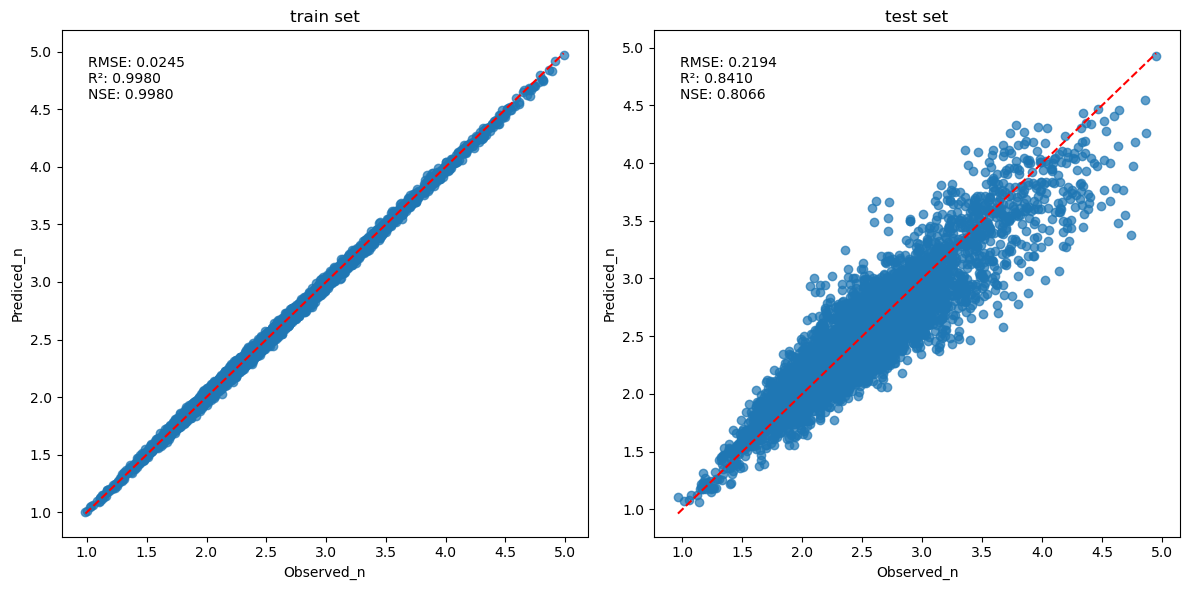

In [ ]:
# 绘制训练集拟合图
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel('Observed_n')
plt.ylabel('Prediced_n')
plt.title('train set')
plt.text(0.05, 0.95, f"RMSE: {rmse_train:.4f}\nR²: {r2_train:.4f}\nNSE: {nse_train:.4f}", 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Observed_n')
plt.ylabel('Prediced_n')
plt.title('test set')
plt.text(0.05, 0.95, f"RMSE: {rmse_test:.4f}\nR²: {r2_test:.4f}\nNSE: {nse_test:.4f}", 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

In [28]:
# 预测
new_data_path = r'01_12_clusters_data\\12.csv'  # 与上面的路径一致
new_data = pd.read_csv(new_data_path)

# 确保包含所需的特征列
required_columns = ['LON', 'LAT', 'AREA', 'ELE', 'SLP', 'RIVER', 'CLAY', 'SAND', 'SILT', 'CTI', 'SW', 'SPEED', 'LAI', 'SRAD', 'CO2']

# 提取特征
X_new = new_data[required_columns]

# 使用训练好的XGBoost模型进行预测
y_new_pred = opt_xgb.predict(X_new.values)

# 将预测结果添加到数据中
new_data['n'] = y_new_pred

# 保存到新的CSV文件
output_path = r'03_12_clusters_p\\12_p.csv'  # 输出文件路径
new_data.to_csv(output_path, index=False)

print(f"预测结果已保存到文件：{output_path}")

预测结果已保存到文件：03_12_clusters_p\\12_p.csv
